# Reinforcement Learning: From Scratch

This notebook demonstrates how Reinforcement Learning (RL) works using a classic example: **GridWorld**.

An agent learns to navigate a grid from a start position to a goal — entirely by trial and error.

---

## Core Concepts

| Concept | Description |
|---|---|
| **Agent** | The learner (our navigator) |
| **Environment** | The GridWorld it lives in |
| **State** | Current position on the grid |
| **Action** | Move: Up, Down, Left, Right |
| **Reward** | +10 for goal, -1 per step, -5 for wall |
| **Policy** | The strategy the agent learns |
| **Q-Table** | Stores learned value of each (state, action) pair |

## 1. Setup & Imports

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.animation as animation
from IPython.display import HTML
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

## 2. The Environment: GridWorld

```
┌───┬───┬───┬───┬───┐
│ S │   │   │ W │   │
├───┼───┼───┼───┼───┤
│   │ W │   │   │   │
├───┼───┼───┼───┼───┤
│   │   │   │ W │   │
├───┼───┼───┼───┼───┤
│   │ W │   │   │   │
├───┼───┼───┼───┼───┤
│   │   │ W │   │ G │
└───┴───┴───┴───┴───┘
S = Start, G = Goal, W = Wall
```

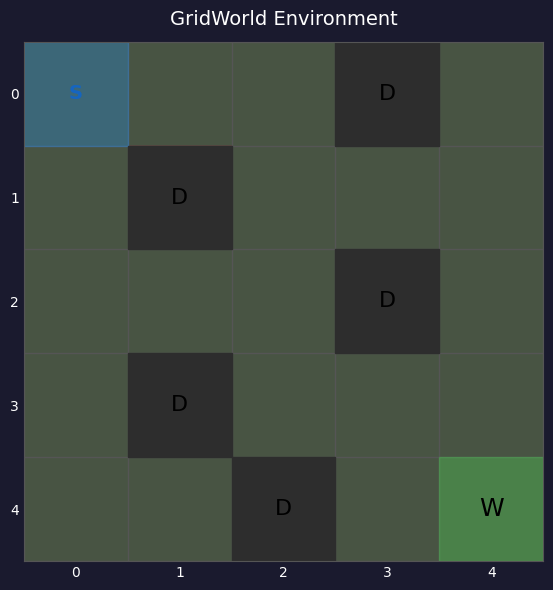

Grid size: 5x5 | States: 25 | Actions: 4


In [12]:
class GridWorld:
    """A 5x5 GridWorld environment."""
    
    def __init__(self, size=5):
        self.size = size
        self.start = (0, 0)
        self.goal  = (4, 4)
        
        # Wall cells the agent cannot enter
        self.walls = {(0,3), (1,1), (2,3), (3,1), (4,2)}
        
        # Actions: 0=Up, 1=Down, 2=Left, 3=Right
        self.action_deltas = {
            0: (-1,  0),  # Up
            1: ( 1,  0),  # Down
            2: ( 0, -1),  # Left
            3: ( 0,  1),  # Right
        }
        self.action_names = ['↑ Up', '↓ Down', '← Left', '→ Right']
        self.n_actions = 4
        self.n_states  = size * size
        
        self.state = self.start
    
    def reset(self):
        self.state = self.start
        return self._pos_to_idx(self.state)
    
    def _pos_to_idx(self, pos):
        return pos[0] * self.size + pos[1]
    
    def _idx_to_pos(self, idx):
        return (idx // self.size, idx % self.size)
    
    def step(self, action):
        dr, dc = self.action_deltas[action]
        new_r  = self.state[0] + dr
        new_c  = self.state[1] + dc
        new_pos = (new_r, new_c)
        
        # Check boundaries and walls
        hit_wall = (
            new_r < 0 or new_r >= self.size or
            new_c < 0 or new_c >= self.size or
            new_pos in self.walls
        )
        
        if hit_wall:
            reward = -5 # Penalty for hitting a wall
        else:
            self.state = new_pos
            reward = -1 # Small step penalty to encourage efficiency
        
        done = (self.state == self.goal)
        if done:
            reward = 10 # Big reward for reaching the goal!
        
        return self._pos_to_idx(self.state), reward, done
    
    def render(self, ax=None, q_table=None, path=None):
        if ax is None:
            fig, ax = plt.subplots(figsize=(6, 6))
        
        grid = np.zeros((self.size, self.size))
        
        for (r, c) in self.walls:
            grid[r, c] = -1
        
        cmap = LinearSegmentedColormap.from_list('grid', ['#2d2d2d', '#f5f5f0', '#4CAF50'])
        ax.imshow(grid, cmap='RdYlGn', vmin=-2, vmax=1, alpha=0.3)
        
        # Draw grid lines
        for i in range(self.size + 1):
            ax.axhline(i - 0.5, color='#555', linewidth=1)
            ax.axvline(i - 0.5, color='#555', linewidth=1)
        
        # Draw cells
        for r in range(self.size):
            for c in range(self.size):
                pos = (r, c)
                if pos in self.walls:
                    ax.add_patch(plt.Rectangle((c-0.5, r-0.5), 1, 1, color='#2d2d2d', zorder=2))
                    ax.text(c, r, 'D', ha='center', va='center', fontsize=16, zorder=3)
                elif pos == self.goal:
                    ax.add_patch(plt.Rectangle((c-0.5, r-0.5), 1, 1, color='#4CAF50', alpha=0.5, zorder=2))
                    ax.text(c, r, 'W', ha='center', va='center', fontsize=18, zorder=3)
                elif pos == self.start:
                    ax.add_patch(plt.Rectangle((c-0.5, r-0.5), 1, 1, color='#2196F3', alpha=0.3, zorder=2))
                    ax.text(c, r, 'S', ha='center', va='center', fontsize=14, fontweight='bold', color='#1565C0', zorder=3)
                
                # Draw best action arrow from Q-table
                if q_table is not None and pos not in self.walls and pos != self.goal:
                    state_idx = self._pos_to_idx(pos)
                    best_action = np.argmax(q_table[state_idx])
                    arrows = ['↑','↓','←','→']
                    ax.text(c, r + 0.3, arrows[best_action],
                            ha='center', va='center', fontsize=13, color='#333', zorder=4)
        
        # Draw learned path
        if path:
            path_r = [self._idx_to_pos(s)[0] for s in path]
            path_c = [self._idx_to_pos(s)[1] for s in path]
            ax.plot(path_c, path_r, 'o-', color='#FF5722', linewidth=2.5,
                    markersize=6, zorder=5, alpha=0.8, label='Learned path')
        
        ax.set_xticks(range(self.size))
        ax.set_yticks(range(self.size))
        ax.set_xticklabels(range(self.size))
        ax.set_yticklabels(range(self.size))
        ax.tick_params(length=0)
        
        return ax


env = GridWorld()

fig, ax = plt.subplots(figsize=(6, 6))
ax.set_facecolor('#1a1a2e')
fig.patch.set_facecolor('#1a1a2e')
env.render(ax)
ax.set_title('GridWorld Environment', color='white', fontsize=14, pad=12)
ax.tick_params(colors='white')
for spine in ax.spines.values(): spine.set_edgecolor('#555')
plt.tight_layout()
plt.show()
print(f"Grid size: {env.size}x{env.size} | States: {env.n_states} | Actions: {env.n_actions}")

## 3. The Algorithm: Q-Learning

**Q-Learning** is a model-free RL algorithm. It learns a **Q-Table** mapping every (state, action) pair to an expected future reward.

### The Bellman Update Equation

$$Q(s, a) \leftarrow Q(s, a) + \alpha \Big[ r + \gamma \max_{a'} Q(s', a') - Q(s, a) \Big]$$

| Symbol | Name | Meaning |
|--------|------|---------|
| $\alpha$ | Learning rate | How fast we update (0–1) |
| $\gamma$ | Discount factor | How much we value future rewards |
| $r$ | Reward | Immediate reward from the environment |
| $\max Q(s',a')$ | Future value | Best possible future Q-value |

### Exploration vs Exploitation (ε-Greedy)

- With probability **ε** → take a **random action** (explore)
- With probability **1-ε** → take the **best known action** (exploit)

In [13]:
class QLearningAgent:
    """Q-Learning agent with epsilon-greedy exploration."""
    
    def __init__(self, n_states, n_actions, alpha=0.1, gamma=0.95, epsilon=1.0, epsilon_min=0.01, epsilon_decay=0.995):
        self.n_states = n_states
        self.n_actions = n_actions
        self.alpha = alpha # Learning rate
        self.gamma = gamma # Discount factor
        self.epsilon = epsilon # Exploration rate
        self.epsilon_min = epsilon_min
        self.epsilon_decay = epsilon_decay
        
        # Initialize Q-table with zeros
        self.q_table = np.zeros((n_states, n_actions))
    
    def choose_action(self, state):
        """ε-greedy action selection."""
        if np.random.random() < self.epsilon:
            return np.random.randint(self.n_actions) # Explore
        return np.argmax(self.q_table[state]) # Exploit
    
    def update(self, state, action, reward, next_state, done):
        """Apply the Bellman equation to update the Q-table."""
        current_q = self.q_table[state, action]
        
        if done:
            target = reward
        else:
            target = reward + self.gamma * np.max(self.q_table[next_state])
        
        # Q-Learning update
        self.q_table[state, action] += self.alpha * (target - current_q)
    
    def decay_epsilon(self):
        """Reduce exploration over time."""
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)


agent = QLearningAgent(
    n_states = env.n_states,
    n_actions = env.n_actions,
    alpha = 0.1,
    gamma = 0.95,
    epsilon = 1.0,
    epsilon_decay = 0.995
)

print(f"Q-table shape: {agent.q_table.shape}  ({env.n_states} states x {env.n_actions} actions)")
print(f"Starting epsilon (exploration rate): {agent.epsilon}")

Q-table shape: (25, 4)  (25 states x 4 actions)
Starting epsilon (exploration rate): 1.0


## 4. Training Loop

Each **episode** is one full attempt from start to goal (or timeout). Over thousands of episodes, the agent learns which actions lead to better outcomes.

In [14]:
def train(env, agent, n_episodes=2000, max_steps=100):
    rewards_history = []
    steps_history = []
    epsilon_history = []
    success_history = []
    
    for episode in range(n_episodes):
        state   = env.reset()
        total_reward = 0
        steps   = 0
        success = False
        
        for step in range(max_steps):
            action = agent.choose_action(state)
            next_state, reward, done = env.step(action)
            
            agent.update(state, action, reward, next_state, done)
            
            state = next_state
            total_reward += reward
            steps += 1
            
            if done:
                success = True
                break
        
        agent.decay_epsilon()
        
        rewards_history.append(total_reward)
        steps_history.append(steps)
        epsilon_history.append(agent.epsilon)
        success_history.append(int(success))
        
        if (episode + 1) % 250 == 0:
            avg_reward  = np.mean(rewards_history[-250:])
            avg_steps   = np.mean(steps_history[-250:])
            success_rate = np.mean(success_history[-250:]) * 100
            print(f" Episode {episode+1:4d}, epsilon ={agent.epsilon:.3f}, Avg Reward: {avg_reward:6.2f}, Avg Steps: {avg_steps:5.1f}, Success Rate: {success_rate:.0f}%")
    
    return rewards_history, steps_history, epsilon_history, success_history


print("Training w/ 2k episodes: ")
rewards_h, steps_h, epsilon_h, success_h = train(env, agent, n_episodes=2000)

Training w/ 2k episodes: 
 Episode  250, epsilon =0.286, Avg Reward: -43.30, Avg Steps:  24.3, Success Rate: 94%
 Episode  500, epsilon =0.082, Avg Reward:  -0.72, Avg Steps:   9.4, Success Rate: 100%
 Episode  750, epsilon =0.023, Avg Reward:   2.13, Avg Steps:   8.4, Success Rate: 100%
 Episode 1000, epsilon =0.010, Avg Reward:   2.81, Avg Steps:   8.1, Success Rate: 100%
 Episode 1250, epsilon =0.010, Avg Reward:   2.83, Avg Steps:   8.1, Success Rate: 100%
 Episode 1500, epsilon =0.010, Avg Reward:   2.79, Avg Steps:   8.1, Success Rate: 100%
 Episode 1750, epsilon =0.010, Avg Reward:   2.81, Avg Steps:   8.1, Success Rate: 100%
 Episode 2000, epsilon =0.010, Avg Reward:   2.78, Avg Steps:   8.1, Success Rate: 100%


## 5. Training Results

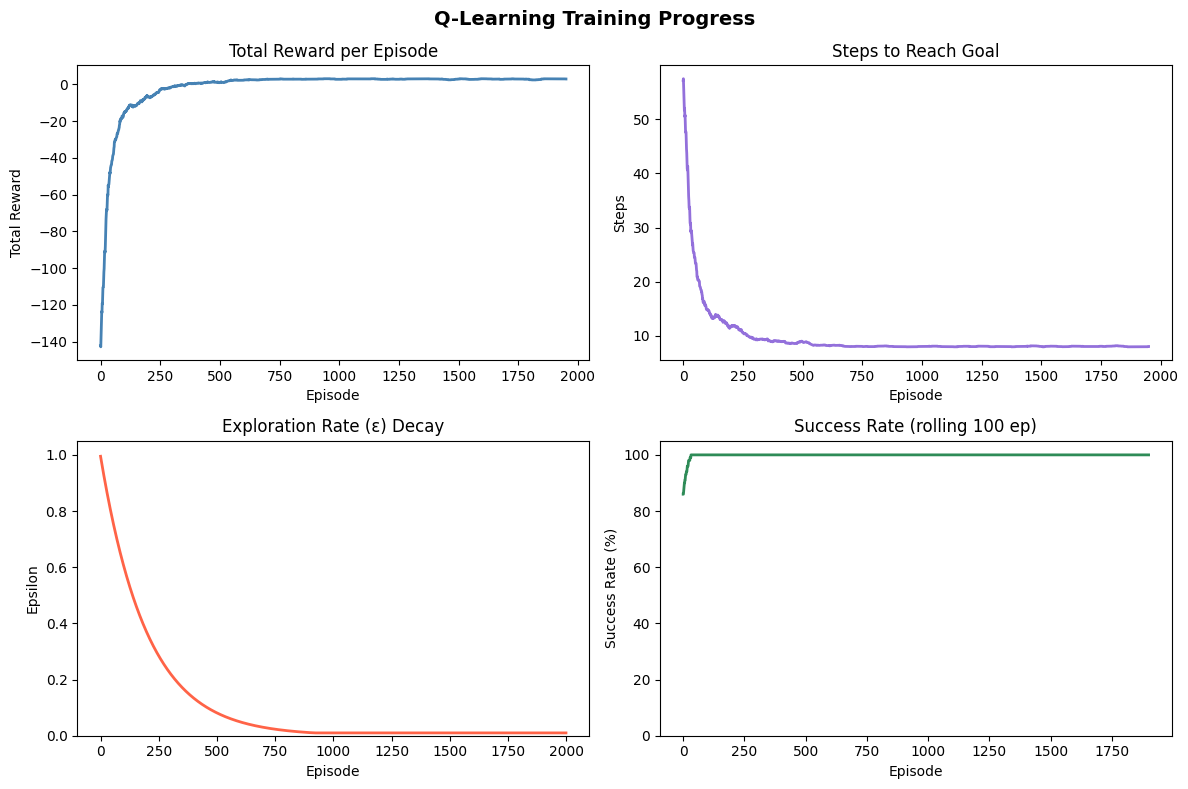

In [15]:
def smooth(data, window=50):
    return np.convolve(data, np.ones(window)/window, mode='valid')

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
episodes = range(len(rewards_h))

# 1. Total Reward per Episode
axes[0,0].plot(smooth(rewards_h), color='steelblue', linewidth=2)
axes[0,0].set_title('Total Reward per Episode')
axes[0,0].set(xlabel='Episode', ylabel='Total Reward')

# 2. Steps per Episode
axes[0,1].plot(smooth(steps_h), color='mediumpurple', linewidth=2)
axes[0,1].set_title('Steps to Reach Goal')
axes[0,1].set(xlabel='Episode', ylabel='Steps')

# 3. Epsilon Decay
axes[1,0].plot(episodes, epsilon_h, color='tomato', linewidth=2)
axes[1,0].set_title('Exploration Rate (ε) Decay')
axes[1,0].set(xlabel='Episode', ylabel='Epsilon', ylim=(0, 1.05))

# 4. Rolling Success Rate
win = 100
success_rate = np.convolve(success_h, np.ones(win)/win, mode='valid') * 100
axes[1,1].plot(success_rate, color='seagreen', linewidth=2)
axes[1,1].set_title(f'Success Rate (rolling {win} ep)')
axes[1,1].set(xlabel='Episode', ylabel='Success Rate (%)', ylim=(0, 105))

fig.suptitle('Q-Learning Training Progress', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. The Learned Q-Table

Let's visualize what the agent has learned — the best action in every cell.

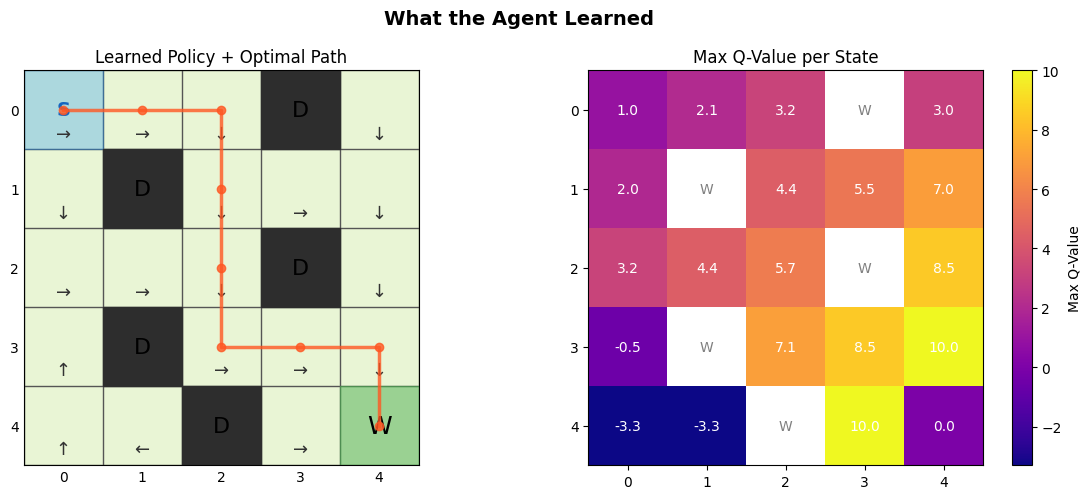

Learned path length: 8 steps
Path: (0, 0)->(0, 1)->(0, 2)->(1, 2)->(2, 2)->(3, 2)->(3, 3)->(3, 4)->(4, 4)


In [16]:
def get_learned_path(env, agent, max_steps=50):
    state = env.reset()
    path = [state]
    for _ in range(max_steps):
        action = np.argmax(agent.q_table[state])
        state, _, done = env.step(action)
        path.append(state)
        if done:
            break
    return path

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: GridWorld with learned policy
path = get_learned_path(env, agent)
env.render(axes[0], q_table=agent.q_table, path=path)
axes[0].set_title('Learned Policy + Optimal Path')

# Right: Q-Table heatmap
max_q = np.max(agent.q_table, axis=1).reshape(env.size, env.size)
for (r, c) in env.walls:
    max_q[r, c] = np.nan

im = axes[1].imshow(max_q, cmap='plasma', interpolation='nearest')
plt.colorbar(im, ax=axes[1], label='Max Q-Value')

for r in range(env.size):
    for c in range(env.size):
        label = f'{max_q[r,c]:.1f}' if (r, c) not in env.walls else 'W'
        color = 'white' if (r, c) not in env.walls else 'gray'
        axes[1].text(c, r, label, ha='center', va='center', fontsize=10, color=color)

axes[1].set_title('Max Q-Value per State')

fig.suptitle('What the Agent Learned', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Learned path length: {len(path)-1} steps")
print(f"Path: {'->'.join(str(env._idx_to_pos(s)) for s in path)}")

## 7. Before vs After: Agent Behavior

In [17]:
def simulate_episode(env, agent, greedy=True, max_steps=50):
    state, total_reward, steps, actions_taken = env.reset(), 0, 0, []
    for _ in range(max_steps):
        action = np.argmax(agent.q_table[state]) if greedy else np.random.randint(env.n_actions)
        actions_taken.append(env.action_names[action])
        state, reward, done = env.step(action)
        total_reward += reward
        steps += 1
        if done:
            break
    return total_reward, steps, done, actions_taken

def print_results(label, results):
    success = sum(r[2] for r in results)
    print(f"\n{label}")
    print(f"  Success rate : {success}/100 episodes")
    print(f"  Avg reward   : {np.mean([r[0] for r in results]):.2f}")
    print(f"  Avg steps    : {np.mean([r[1] for r in results]):.1f}")

print_results("Random Agent (before learning)", [simulate_episode(env, agent, greedy=False) for _ in range(100)])
print_results("Trained Agent (after Q-learning)", [simulate_episode(env, agent, greedy=True) for _ in range(100)])

_, _, _, actions = simulate_episode(env, agent, greedy=True)
print(f"\nOptimal path actions:\n  {' -> '.join(actions)}")


Random Agent (before learning)
  Success rate : 22/100 episodes
  Avg reward   : -129.36
  Avg steps    : 46.5

Trained Agent (after Q-learning)
  Success rate : 100/100 episodes
  Avg reward   : 3.00
  Avg steps    : 8.0

Optimal path actions:
  → Right -> → Right -> ↓ Down -> ↓ Down -> ↓ Down -> → Right -> → Right -> ↓ Down


## 8. Hyperparameter Sensitivity

How do different learning rates (α) and discount factors (γ) affect performance?

### Key Takeaways

1. **Trial and Error** — The agent starts knowing nothing and learns purely from rewards and penalties.

2. **Exploration vs Exploitation** — epsilon-greedy balances trying new things vs using what's been learned. Epsilon decays so the agent explores less as it gets smarter.

3. **The Q-Table** — Encodes the agent's knowledge. Each cell stores how valuable a (state, action) pair is in the long run.

4. **Learning Rate α** — Too small → learns slowly. Too large → unstable/overshoots. ~0.1 is a good default.

5. **Discount Factor γ** — High gamma (≈1) makes the agent value future rewards. Low γ makes it short-sighted.